# Kimberly Libranza: C22386221

This contains the functions to 

Selected: C:\Users\Kimberly\Desktop\Academics\Yr4\IMG_Processing\Volleyball-Line-Detection\sample_images\Sample_Input_1.jpg


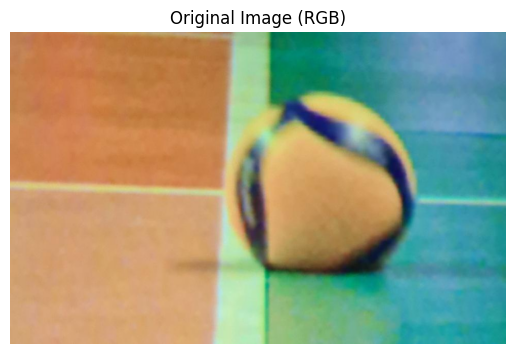

In [187]:
# Initial block for image loading and normalising, we should use this as the base 
# for both the line detection and ball detection so we have a consistent image variables.

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import easygui

# Let the user pick an image
input_path = easygui.fileopenbox("Select volleyball court image:")
print("Selected:", input_path)

image_bgr = cv.imread(input_path)
if image_bgr is None:
    raise ValueError("Could not read image, check the path.")

# resize to a consistent width
target_width = 800
h, w = image_bgr.shape[:2]
scale = target_width / w
image_bgr = cv.resize(image_bgr, (target_width, int(h * scale)))

# Convert to RGB for matplotlib
image_rgb = cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image (RGB)")
plt.axis("off")
plt.show()

This function creates a binary mask isolating the ball from the rest of the image. It uses adaptive thresholding on the Y channel of the YCrCb color space and morphological operations to clean up the mask before returning the final binary mask.

**Input: BGR image** \
**Output: Binary mask**

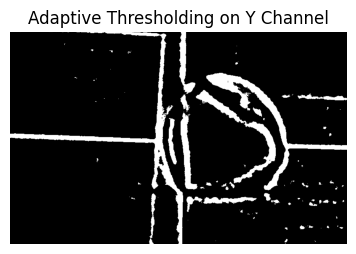

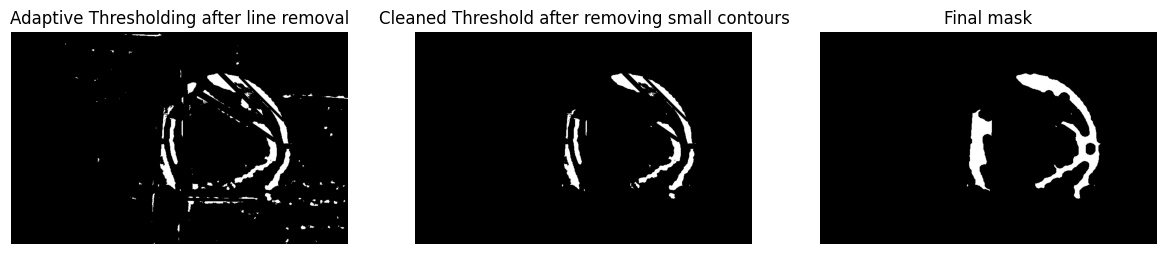

In [188]:
def create_ball_mask(image_bgr):
    # Denoising and convert to Ycrcb color space
    image_bgr = cv.GaussianBlur(image_bgr, (5, 5), 0)
    image_ycrcb = cv.cvtColor(image_bgr, cv.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv.split(image_ycrcb)

    # Adatptive thresholding on Y channel which filters out some lines and the ball
    adaptive_thresh = cv.adaptiveThreshold(Y, maxValue=255, adaptiveMethod=cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           thresholdType=cv.THRESH_BINARY, blockSize=49, C=-5)

    # Displays the adaptive threshold result (can be removed if you want)
    plt.figure(figsize=(20,10))
    plt.subplot(1,4,1)
    plt.title('Adaptive Thresholding on Y Channel')
    plt.imshow(adaptive_thresh, cmap='gray')
    plt.axis('off')

    ## -----This section removes court lines from the thresholded image---- ##
    
    # Detect the inner and outer edge of the court line using hough transform
    lines = cv.HoughLinesP(adaptive_thresh, rho=1, theta=np.pi/180, threshold=200,
                            minLineLength=50, maxLineGap=10)

    # Remove detected lines from adaptive_thresh
    if lines is not None: 
        for line in lines:
            x1, y1, x2, y2 = line[0] # Extract line endpoints
            cv.line(adaptive_thresh, pt1=(x1, y1), pt2=(x2, y2), color=(0), thickness=5)
    ## --------------------------------------------------------------- ##

    # Remove the noise by removing small contours
    contours, _ = cv.findContours(adaptive_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    min_contour_area = 400
    cleaned_thresh = np.zeros_like(adaptive_thresh)
    for contour in contours:
        if cv.contourArea(contour) >= min_contour_area:
            cv.drawContours(cleaned_thresh, [contour], -1, color=255, thickness=-1)

    # Close gaps in the detected contours
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
    closed_thresh = cv.morphologyEx(cleaned_thresh, cv.MORPH_CLOSE, kernel, iterations=2)

    # Dialate to further close gaps
    closed_thresh = cv.dilate(closed_thresh, kernel, iterations=10)

    # Remove more small noise
    closed_thresh = cv.morphologyEx(closed_thresh, cv.MORPH_OPEN, kernel, iterations=2)

    # Combine with original adaptive threshold to ensure only relevant areas are left
    cleaned_thresh = cv.bitwise_and(closed_thresh, adaptive_thresh, mask=closed_thresh)

    # Close gaps
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (11,11))
    final_mask = cv.morphologyEx(cleaned_thresh, cv.MORPH_CLOSE, kernel, iterations=2)

    # Displays the results (can be removed if you want)
    plt.figure(figsize=(20,10))
    plt.subplot(1,4,2)
    plt.title('Adaptive Thresholding after line removal')
    plt.imshow(adaptive_thresh, cmap='gray')
    plt.axis('off')
    plt.subplot(1,4,3)
    plt.title('Cleaned Threshold after removing small contours')
    plt.imshow(cleaned_thresh, cmap='gray')
    plt.axis('off')
    plt.subplot(1,4,4)
    plt.title('Final mask')
    plt.imshow(final_mask, cmap='gray')
    plt.axis('off')

    return final_mask

ball_mask = create_ball_mask(image_bgr)



This function detects the ball using the mask created, finds contours in the mask, combines the two largest contours into one and draws the detection circle around them on the original image.

**Input: RGB image, binary ball mask** \
**Output: RGB image with detected ball outlined**

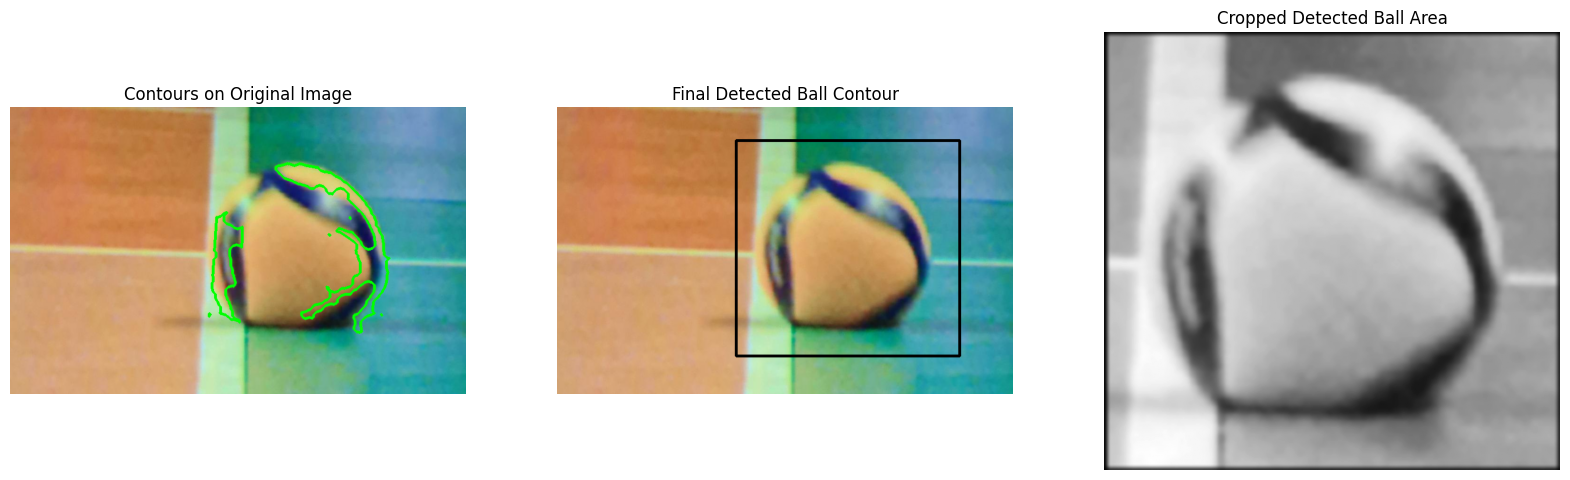

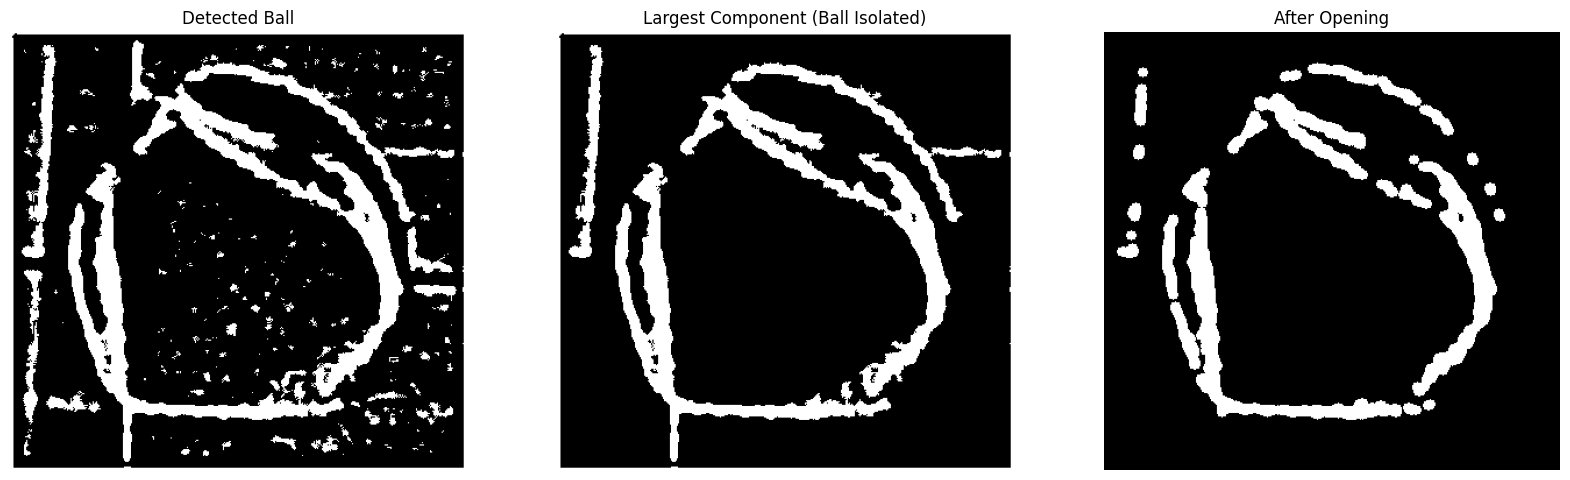

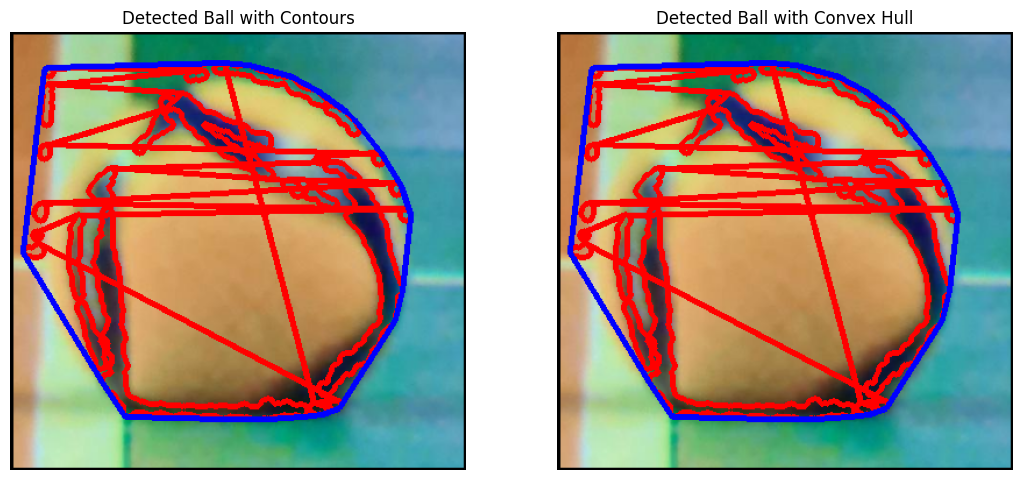

In [189]:
def detect_ball(image_rgb, ball_mask):
    
    # Find contours that are circular in shape
    contours, _ = cv.findContours(ball_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    image_rgb_contours = image_rgb.copy()
    image_rgb_contours = cv.drawContours(image_rgb_contours, contours=contours, contourIdx=-1, color=(0,255,0), thickness=3)

    # Combine the two largest contours
    contours = sorted(contours, key=cv.contourArea)
    largest_contour = max(contours, key=cv.contourArea)
    second_largest_contour = contours[-2]
    combined_contour = np.concatenate((largest_contour, second_largest_contour))

    """# Draw a circle around the combined contour
    (x, y), radius = cv.minEnclosingCircle(combined_contour)
    center = (int(x), int(y))
    radius = int(radius)
    image_rgb = cv.circle(image_rgb, center, radius, color=(0,255,0), thickness=7)
"""
    # Get the bounding box of the contours and add a safe margin
    x, y, w, h = cv.boundingRect(combined_contour)
    margin = 40
    bounding_box_img = image_rgb.copy()
    bounding_box_img = cv.rectangle(bounding_box_img, (x - margin, y - margin), (x + w + margin, y + h + margin), color=(0), thickness=3)

    # Crop the detected ball area
    detected_ball = bounding_box_img[y - margin:y + h + margin, x - margin:x + w + margin]

    ## ----- Futher prerocessing to isolate the ball ---- ##
    detected_ball_grey = cv.cvtColor(detected_ball, cv.COLOR_RGB2GRAY)
    detected_ball_blur = cv.GaussianBlur(detected_ball_grey, (7,7), 0)

    ball_threshold = cv.adaptiveThreshold(detected_ball_blur, maxValue=255, adaptiveMethod=cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           thresholdType=cv.THRESH_BINARY_INV, blockSize=21, C=2)

    # Apply components analysis to keep only the largest component
    total_labels, label_ids, stats, _ = cv.connectedComponentsWithStats(ball_threshold, connectivity=4, stats=cv.CV_32S)

    output = np.zeros_like(ball_threshold)

    # Keep only components that are larger than a certain area threshold
    for i in range(1, total_labels):
        if stats[i, cv.CC_STAT_AREA] >= 800: 
            component_mask = (label_ids == i).astype("uint8") * 255
            output = cv.bitwise_or(output, component_mask)
                
    # Open to smooth edges
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (9,9))
    open_output = cv.morphologyEx(output, cv.MORPH_OPEN, kernel, iterations=1)
    #close_output = cv.morphologyEx(open_output, cv.MORPH_CLOSE, kernel, iterations=1)

    ## -------------------------------------------------- ##

    # Detect contours on the final output
    ball_contours, _ = cv.findContours(open_output, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

    # connect all the outlines to form a single contour
    if len(ball_contours) > 0:
        final_ball_contour = np.concatenate(ball_contours)
        #draw the final contour on the bounding box image
        detected_ball_drawn_contours = detected_ball.copy()
        detected_ball_drawn_contours = cv.drawContours(detected_ball_drawn_contours, contours=[final_ball_contour], contourIdx=-1, color=(255,0,0), thickness=3)

    # Convex hull of the final contour
    if len(ball_contours) > 0:
        hull = cv.convexHull(final_ball_contour)
        detected_ball_drawn_convex = detected_ball.copy()
        detected_ball_drawn_convex = cv.drawContours(detected_ball_drawn_contours, contours=[hull], contourIdx=-1, color=(0,0,255), thickness=3)

    # Displays the results
    plt.figure(figsize=(20,10))
    plt.subplot(1,3,1)
    plt.title('Contours on Original Image')
    plt.imshow(image_rgb_contours)
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.title('Final Detected Ball Contour')
    plt.imshow(bounding_box_img)
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.title('Cropped Detected Ball Area')
    plt.imshow(detected_ball_blur, cmap='gray')
    plt.axis('off')

    plt.figure(figsize=(20,10))
    plt.subplot(1,3,1)
    plt.title('Detected Ball')
    plt.imshow(ball_threshold, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.title('Largest Component (Ball Isolated)')
    plt.imshow(output, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.title('After Opening')
    plt.imshow(open_output, cmap='gray')
    plt.axis('off')
    
    plt.figure(figsize=(20,10))
    plt.subplot(1,3,1)
    plt.title('Detected Ball with Contours')
    plt.imshow(detected_ball_drawn_contours)
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.title('Detected Ball with Convex Hull')
    plt.imshow(detected_ball_drawn_convex)
    plt.axis('off')

    return image_rgb

detected_image = detect_ball(image_rgb, ball_mask)
